# Record-Level 3-Class CTG Classification with Windowing

**Goal**: Achieve higher 3-class accuracy by training on multiple windows per record and aggregating window predictions back to record-level predictions.

**Key Features**:
- Windowing strategy to increase effective training data WITHOUT leakage
- Group-aware cross-validation (all windows from same record stay in same fold)
- Transfer learning from binary baseline model
- Record-level prediction via aggregation of window predictions
- Configurable window length, number of windows, and aggregation method

## Section 1: Imports, Seeds & Environment Setup

In [2]:
import pandas as pd
import numpy as np
import wfdb
import json
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, DepthwiseConv2D, SeparableConv2D,
    BatchNormalization, Activation, AveragePooling2D,
    Dropout, GlobalAveragePooling2D, Dense, Concatenate
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix, classification_report, f1_score,
    accuracy_score, precision_score, recall_score,
    balanced_accuracy_score
)
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from collections import defaultdict

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.16.1
Numpy version: 1.26.4
GPU Available: []


## Section 2: Data Loading & Preprocessing (Same as Baseline)

In [3]:
# Signal preprocessing functions (same as baseline)

def remove_trailing_zeros(signal):
    """Remove trailing zeros from a signal."""
    if not isinstance(signal, list):
        raise ValueError("Input signal must be a list.")
    
    last_non_zero_index = len(signal) - 1
    while last_non_zero_index >= 0 and signal[last_non_zero_index] == 0:
        last_non_zero_index -= 1
    
    return signal[:last_non_zero_index + 1]

def extract_last_30_minutes(signal, sampling_rate=4):
    """Extract last 30 minutes of signal."""
    num_samples_30_minutes = 30 * 60 * sampling_rate
    if len(signal) < num_samples_30_minutes:
        return []
    return signal[-num_samples_30_minutes:]

def downsample_to_1hz(signal, original_fs=4, target_fs=1):
    """Downsample signal to 1 Hz."""
    factor = original_fs // target_fs
    return signal[::factor]

def is_signal_acceptable(signal, threshold=0.16):
    """Check if signal loss is within acceptable threshold."""
    if not signal or len(signal) == 0:
        return False
    total_length = len(signal)
    zero_count = signal.count(0)
    signal_loss = zero_count / total_length
    return signal_loss < threshold

print("Preprocessing functions defined")

Preprocessing functions defined


In [4]:
# Load raw CTG records
raw_dataset = Path("../data/raw_dataset")
records = [p.stem for p in raw_dataset.glob("*.hea")]
print(f"Found {len(records)} CTG records")

# Process all records
processed_records = []

for rec in records:
    record = wfdb.rdrecord(raw_dataset / rec)
    signals = record.p_signal
    
    fhr = signals[:, 0].tolist()
    uc  = signals[:, 1].tolist()
    
    # Apply preprocessing pipeline
    fhr = remove_trailing_zeros(fhr)
    uc  = remove_trailing_zeros(uc)
    fhr = extract_last_30_minutes(fhr, sampling_rate=record.fs)
    uc  = extract_last_30_minutes(uc, sampling_rate=record.fs)
    fhr = downsample_to_1hz(fhr, original_fs=record.fs, target_fs=1)
    uc  = downsample_to_1hz(uc, original_fs=record.fs, target_fs=1)
    
    # Selection
    if is_signal_acceptable(fhr) and is_signal_acceptable(uc):
        processed_records.append({
            "rec_id": rec,
            "FHR": fhr,
            "UC": uc
        })

data_df = pd.DataFrame(processed_records)
print(f"Processed {len(data_df)} records that passed quality criteria")

Found 552 CTG records
Processed 220 records that passed quality criteria


In [5]:
# Load 3-class labels
labels_df = pd.read_csv('../ExpertAnnotations/CTG_Majority_Vote_Labels_FINAL.csv')
print(f"Label columns: {labels_df.columns.tolist()}")
print(f"\nRaw label distribution:")
print(labels_df['Clinical_Label'].value_counts())

Label columns: ['rec_id', 'Majority_Vote_Label', 'Clinical_Label']

Raw label distribution:
Clinical_Label
No Hypoxia (Normal)          426
Mild Hypoxia (Suspicious)    126
Name: count, dtype: int64


In [6]:
# Merge with labels
data_df['rec_id'] = data_df['rec_id'].astype(str)
labels_df['rec_id'] = labels_df['rec_id'].astype(str)

merged_df = data_df.merge(
    labels_df,
    left_on="rec_id",
    right_on="rec_id",
    how="inner"
)

print(f"Merged dataset shape: {merged_df.shape}")
print(f"\nLabel distribution:")
print(merged_df["Clinical_Label"].value_counts())

Merged dataset shape: (220, 5)

Label distribution:
Clinical_Label
No Hypoxia (Normal)          164
Mild Hypoxia (Suspicious)     56
Name: count, dtype: int64


## Section 3: Label Preparation for 3-Class Classification

In [7]:
# Define stable 3-class mapping
# path to majority voting labels
Labels = '..\ExpertAnnotations\step3_labels.csv'

# print number of normal and abnormal deliveries
labels_df = pd.read_csv(Labels)
num_normal = sum(labels_df['Clinical_Label'] == 'No Hypoxia (Normal)')
num_suspicious = sum(labels_df['Clinical_Label'] == 'Mild Hypoxia (Suspicious)')
num_severe = sum(labels_df['Clinical_Label'] == 'Severe Hypoxia (Pathological)')
num_uninterpretable = sum(labels_df['Clinical_Label'] == 'Uninterpretable (Filtered)')
print(f'Number of normal deliveries: {num_normal}')
print(f'Number of suspicious deliveries: {num_suspicious}')
print(f'Number of severe deliveries: {num_severe}')
print(f'Number of uninterpretable deliveries: {num_uninterpretable}')

Number of normal deliveries: 127
Number of suspicious deliveries: 153
Number of severe deliveries: 57
Number of uninterpretable deliveries: 215


In [8]:
'''
Map the labels
'''

# Create a mapping from record ID to clinical label
labels_df = pd.read_csv(Labels)
print(labels_df.columns)

data_df['rec_id'] = data_df['rec_id'].astype(str)
labels_df['rec_id'] = labels_df['rec_id'].astype(str)
merged_df = data_df.merge(
    labels_df,
    left_on="rec_id",
    right_on="rec_id",
    how="inner"
)

print(merged_df.shape)
label_counts = merged_df['Clinical_Label'].value_counts()
print(label_counts)


Index(['rec_id', 'Majority_Vote_Label', 'Clinical_Label'], dtype='object')
(220, 5)
Clinical_Label
Uninterpretable (Filtered)       91
Mild Hypoxia (Suspicious)        57
No Hypoxia (Normal)              42
Severe Hypoxia (Pathological)    30
Name: count, dtype: int64


In [9]:
# Prepare 3-class labels and record IDs
UNINT = "Uninterpretable (Filtered)"
MAP_3 = {
    "No Hypoxia (Normal)": 0,
    "Mild Hypoxia (Suspicious)": 1,
    "Severe Hypoxia (Pathological)": 2
}

# Build X - (N_records, 2, 1800, 1)
X = np.array([
    np.stack([row["FHR"], row["UC"]], axis=0)
    for _, row in merged_df.iterrows()
], dtype=np.float32)[..., np.newaxis]

# Build y_sev - record labels (0=Normal, 1=Mild, 2=Severe, -1=Uninterpretable)
def map_sev(lbl):
    if lbl == UNINT:
        return -1
    return MAP_3[lbl]

y_sev = merged_df["Clinical_Label"].apply(map_sev).values.astype(np.int32)
record_ids = merged_df["rec_id"].values

# Filter out uninterpretable records for 3-class task
interpretable_mask = (y_sev >= 0)
X_3class = X[interpretable_mask]
y_3class = y_sev[interpretable_mask]
record_ids_3class = record_ids[interpretable_mask]

print(f"Total records: {X.shape[0]}")
print(f"Interpretable records (3-class): {X_3class.shape[0]}")
print(f"\n3-Class distribution:")
for i, name in enumerate(["Normal", "Mild", "Severe"]):
    count = np.sum(y_3class == i)
    print(f"  {name}: {count} ({count/len(y_3class)*100:.1f}%)")
print(f"\nRecord IDs: {len(record_ids_3class)} unique records")
print(f"Signal shape: {X_3class.shape}")

Total records: 220
Interpretable records (3-class): 129

3-Class distribution:
  Normal: 42 (32.6%)
  Mild: 57 (44.2%)
  Severe: 30 (23.3%)

Record IDs: 129 unique records
Signal shape: (129, 2, 1800, 1)


## Section 4: Windowing Functions for Data Augmentation Without Leakage

In [10]:
def sample_windows(x_record, win_len, K, rng):
    """
    Sample K windows from a single record with random start indices.
    
    Args:
        x_record: shape (2, T, 1) - single record
        win_len: target window length  
        K: number of windows to sample
        rng: numpy random generator
    
    Returns:
        windows: shape (K, 2, win_len, 1)
    """
    _, T, _ = x_record.shape
    
    # Case 1: Record length == win_len -> return K copies
    if T == win_len:
        return np.tile(x_record[np.newaxis, ...], (K, 1, 1, 1))
    
    # Case 2: Record shorter than win_len -> pad with reflection
    if T < win_len:
        pad_needed = win_len - T
        # Reflect padding on the time axis
        x_padded = np.pad(x_record, ((0, 0), (0, pad_needed), (0, 0)), mode='reflect')
        return np.tile(x_padded[np.newaxis, ...], (K, 1, 1, 1))
    
    # Case 3: Record longer than win_len -> random crop
    windows = []
    max_start = T - win_len
    for _ in range(K):
        start_idx = rng.integers(0, max_start + 1)
        window = x_record[:, start_idx:start_idx + win_len, :]
        windows.append(window)
    
    return np.array(windows, dtype=np.float32)


def compute_train_fold_stats(X_train_windows):
    """
    Compute channel-wise train-fold statistics for normalization.

    Using train-fold normalization preserves clinically meaningful
    baseline FHR and UC scale differences across records.
    Per-record normalization can remove severity-related signal
    and reduce generalization, especially under transfer learning.

    Args:
        X_train_windows: shape (N, 2, T, 1)

    Returns:
        train_mean: shape (2,)
        train_std: shape (2,)
    """
    train_mean = np.mean(X_train_windows, axis=(0, 2, 3)).astype(np.float32)
    train_std = np.std(X_train_windows, axis=(0, 2, 3)).astype(np.float32)
    return train_mean, train_std


def normalize_with_train_stats(X, train_mean, train_std, eps=1e-8):
    """
    Normalize windows using train-fold channel statistics.

    Args:
        X: shape (N, 2, T, 1)
        train_mean: shape (2,)
        train_std: shape (2,)
        eps: numerical stability term

    Returns:
        X_norm: normalized windows
    """
    mean = train_mean.reshape(1, 2, 1, 1)
    std = (train_std + eps).reshape(1, 2, 1, 1)
    return ((X - mean) / std).astype(np.float32)


def time_shift_augment(x_window, max_shift=50, rng=None):
    """
    Apply time-shift augmentation using pad + crop (no tf.roll).
    
    Args:
        x_window: shape (2, T, 1)
        max_shift: maximum shift in timesteps
        rng: numpy random generator
    
    Returns:
        shifted window: shape (2, T, 1)
    """
    if rng is None:
        rng = np.random.default_rng()
    
    _, T, _ = x_window.shape
    shift = rng.integers(-max_shift, max_shift + 1)
    
    if shift == 0:
        return x_window
    
    # Pad both sides
    x_padded = np.pad(x_window, ((0, 0), (max_shift, max_shift), (0, 0)), mode='edge')
    
    # Crop to get shifted window
    start = max_shift + shift
    return x_padded[:, start:start + T, :]


def add_gaussian_noise(x_window, noise_std=0.05, rng=None):
    """
    Add Gaussian noise to window.
    
    Args:
        x_window: shape (2, T, 1)
        noise_std: standard deviation of noise
        rng: numpy random generator
    
    Returns:
        noisy window: shape (2, T, 1)
    """
    if rng is None:
        rng = np.random.default_rng()
    
    noise = rng.normal(0, noise_std, x_window.shape).astype(np.float32)
    return x_window + noise


print("Windowing functions defined:")
print("  - sample_windows()")
print("  - compute_train_fold_stats()")
print("  - normalize_with_train_stats()")
print("  - time_shift_augment()")
print("  - add_gaussian_noise()")

Windowing functions defined:
  - sample_windows()
  - compute_train_fold_stats()
  - normalize_with_train_stats()
  - time_shift_augment()
  - add_gaussian_noise()


In [11]:
def create_sliding_windows(record, window_size=1800, stride=600):
    """
    Generate deterministic sliding windows from a single record.
    
    IMPORTANT: Using deterministic sliding windows at test-time (instead of random sampling)
    reduces variance in record-level predictions because:
    1. All evaluations see the exact same windows (reproducible)
    2. No sampling bias - we use ALL available signal segments
    3. Overlapping windows capture context better than isolated random crops
    4. Variance in aggregated predictions comes only from model uncertainty, not sampling
    
    Args:
        record: shape (2, T, 1) - single CTG record (FHR, UC)
        window_size: target window length in samples
        stride: sliding window stride (smaller = more overlap)
    
    Returns:
        windows: shape (num_windows, 2, window_size, 1)
        num_windows: total number of windows extracted
    """
    _, T, _ = record.shape
    
    # Case 1: Record shorter than window_size -> pad with reflection
    if T < window_size:
        pad_needed = window_size - T
        record_padded = np.pad(record, ((0, 0), (0, pad_needed), (0, 0)), mode='reflect')
        # Return single window (the padded record)
        return record_padded[np.newaxis, ...], 1
    
    # Case 2: Record equals window_size -> return as-is
    if T == window_size:
        return record[np.newaxis, ...], 1
    
    # Case 3: Record longer than window_size -> sliding windows
    windows = []
    start_idx = 0
    
    # Generate overlapping windows with stride
    while start_idx + window_size <= T:
        window = record[:, start_idx:start_idx + window_size, :]
        windows.append(window)
        start_idx += stride
    
    # Always include the final window (aligned to end) if not already included
    if start_idx < T:
        final_window = record[:, -window_size:, :]
        # Check if this final window differs from the last added window
        if len(windows) == 0 or start_idx + window_size < T:
            windows.append(final_window)
    
    windows = np.array(windows, dtype=np.float32)
    return windows, len(windows)


def aggregate_predictions(window_logits, method="mean_logits", top_k=5, trim_ratio=0.1, rank_mode="per_class"):
    """
    Aggregate window-level predictions to record-level with multiple strategies.

    CRITICAL NOTE ON LOGITS-BASED vs PROBABILITY-BASED AGGREGATION:
    ================================================================
    Logits-based aggregation (method='top_k_logits') is more stable than probability-based
    aggregation for several reasons:
    
    1. **Unbounded vs Bounded**: Logits are unbounded and preserve the full range of model
       confidence. Softmax probabilities are bounded to [0,1] and compressed, losing information.
    
    2. **Local Normalization**: Per-window softmax normalization can mask class-specific
       confidence. Taking top-k logits before aggregating softmax preserves relative logit
       magnitudes across windows.
    
    3. **Transfer Learning Stability**: Under transfer learning, logit scales are better
       preserved from pretraining. Probability-based methods can over- or under-emphasize
       classes depending on model calibration.
    
    4. **Severe Class Detection**: For medical tasks (severe hypoxia detection), logit-based
       top-k with margin ranking naturally prioritizes windows with high severe-class logits,
       while probability-based top-k operates on already-normalized per-window distributions.

    Args:
        window_logits: shape (num_windows, num_classes)
        method: one of {'mean_logits', 'trimmed_mean', 'top_k', 'top_k_logits'}
        top_k: number of top windows per class/ranking for top-k methods
        trim_ratio: fraction trimmed from each tail for 'trimmed_mean'
        rank_mode: ranking strategy for 'top_k_logits':
            - 'per_class': top-k windows per class (default, class-agnostic)
            - 'margin': top-k windows by confidence margin (max_logit - second_max)

    Returns:
        final_probs: shape (num_classes,) - aggregated class probabilities
    """
    num_windows, num_classes = window_logits.shape

    if method == "mean_logits":
        # Average logits then softmax (baseline)
        avg_logits = np.mean(window_logits, axis=0)
        z = avg_logits - np.max(avg_logits)
        exp_z = np.exp(z)
        return exp_z / np.sum(exp_z)

    if method == "top_k_logits":
        """
        Logits-based top-k pooling: select and average top-k window logits before softmax.
        More stable than probability-based pooling because it operates on unbounded
        model outputs and preserves relative confidence scales.
        """
        k = min(max(1, int(top_k)), num_windows)
        
        if rank_mode == "per_class":
            # For each class, select top-k windows with highest logits for that class
            # Vectorized using argsort (O(n log n) but simple and clear)
            agg_logits = np.zeros(num_classes, dtype=np.float32)
            
            for c in range(num_classes):
                class_logits = window_logits[:, c]
                # Get indices of top-k
                top_k_indices = np.argsort(class_logits)[-k:]
                # Average logits for this class
                agg_logits[c] = np.mean(class_logits[top_k_indices])
            
            # Apply numerically stable softmax to aggregated logits
            z = agg_logits - np.max(agg_logits)
            exp_z = np.exp(z)
            return exp_z / np.sum(exp_z)
        
        elif rank_mode == "margin":
            # Rank windows by logit margin (confidence margin = max - second_max)
            # This prioritizes windows where the model is most confident in any decision
            max_logits = np.max(window_logits, axis=1)
            # Second max: partition by max, then get second largest
            kth_largest = -np.partition(-window_logits, 1, axis=1)[:, 1]
            margin = max_logits - kth_largest
            
            # Get top-k windows by margin
            top_k_indices = np.argsort(margin)[-k:]
            
            # Average logits of top-k windows for each class
            agg_logits = np.mean(window_logits[top_k_indices, :], axis=0)
            
            # Apply numerically stable softmax
            z = agg_logits - np.max(agg_logits)
            exp_z = np.exp(z)
            return exp_z / np.sum(exp_z)
        
        else:
            raise ValueError(f"Unknown rank_mode: {rank_mode}. Use 'per_class' or 'margin'.")

    # Softmax per window (numerically stable) for probability-based methods
    shifted = window_logits - np.max(window_logits, axis=1, keepdims=True)
    exp_logits = np.exp(shifted)
    window_probs = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

    if method == "trimmed_mean":
        if num_windows < 3:
            final_probs = np.mean(window_probs, axis=0)
            return final_probs / np.sum(final_probs)

        sorted_probs = np.sort(window_probs, axis=0)
        trim_count = int(np.floor(num_windows * trim_ratio))
        max_trim = (num_windows - 1) // 2
        trim_count = min(trim_count, max_trim)

        if trim_count > 0:
            trimmed = sorted_probs[trim_count:num_windows - trim_count, :]
        else:
            trimmed = sorted_probs

        final_probs = np.mean(trimmed, axis=0)
        return final_probs / np.sum(final_probs)

    if method == "top_k":
        # Probability-based top-k: legacy method, less stable than top_k_logits
        k = min(max(1, int(top_k)), num_windows)
        topk_probs = np.sort(window_probs, axis=0)[-k:, :]
        final_probs = np.mean(topk_probs, axis=0)
        return final_probs / np.sum(final_probs)

    raise ValueError(f"Unknown aggregation method: {method}. Use 'mean_logits', 'trimmed_mean', 'top_k', or 'top_k_logits'.")


print("Test-time windowing functions defined:")
print("  - create_sliding_windows() - deterministic sliding windows")
print("  - aggregate_predictions()")
print("    Available methods: mean_logits, trimmed_mean, top_k, top_k_logits")
print("    Rank modes for top_k_logits: per_class, margin")

Test-time windowing functions defined:
  - create_sliding_windows() - deterministic sliding windows
  - aggregate_predictions()
    Available methods: mean_logits, trimmed_mean, top_k, top_k_logits
    Rank modes for top_k_logits: per_class, margin


## Section 5: Model Architecture with Transfer Learning Support

In [12]:
def build_ctg_ms_cnn_binary(input_shape=(2, 1800, 1), dropout_rate=0.35):
    """
    Build binary CTG Multi-Scale CNN (exact architecture as baseline).
    This is used to load pretrained binary model weights.
    
    Args:
        input_shape: tuple (channels, time_steps, features)
        dropout_rate: dropout rate
    
    Returns:
        Keras Model with binary output (Dense(2))
    """
    inputs = Input(shape=input_shape, name="input")

    # Stage 1: Temporal filtering
    x = Conv2D(filters=4, kernel_size=(1, 3), padding="same", use_bias=False, name="temporal_filter")(inputs)
    x = BatchNormalization(name="bn_stage1")(x)

    # Stage 2: Signal interaction
    x = DepthwiseConv2D(kernel_size=(2, 1), depth_multiplier=2, use_bias=False, name="signal_interaction")(x)
    x = BatchNormalization(name="bn_stage2")(x)
    x = Activation("relu", name="relu_stage2")(x)
    x = AveragePooling2D(pool_size=(1, 4), name="pool_stage2")(x)
    x = Dropout(dropout_rate, name="drop_stage2")(x)

    # Stage 3: Multi-Scale branches
    branch_small = SeparableConv2D(filters=8, kernel_size=(1, 3), padding="same", use_bias=False, name="branch_small")(x)
    branch_small = BatchNormalization(name="bn_branch_small")(branch_small)
    branch_small = Activation("relu", name="relu_branch_small")(branch_small)

    branch_medium = SeparableConv2D(filters=8, kernel_size=(1, 7), padding="same", use_bias=False, name="branch_medium")(x)
    branch_medium = BatchNormalization(name="bn_branch_medium")(branch_medium)
    branch_medium = Activation("relu", name="relu_branch_medium")(branch_medium)

    branch_large = SeparableConv2D(filters=8, kernel_size=(1, 15), padding="same", use_bias=False, name="branch_large")(x)
    branch_large = BatchNormalization(name="bn_branch_large")(branch_large)
    branch_large = Activation("relu", name="relu_branch_large")(branch_large)

    # Concatenate and project
    x = Concatenate(axis=-1, name="concat_branches")([branch_small, branch_medium, branch_large])
    x = Conv2D(filters=8, kernel_size=(1, 1), use_bias=False, name="projection")(x)
    x = BatchNormalization(name="bn_projection")(x)
    x = Activation("relu", name="relu_projection")(x)
    x = AveragePooling2D(pool_size=(1, 4), name="pool_projection")(x)
    x = Dropout(dropout_rate, name="drop_projection")(x)

    # Binary classification head (Dense(2))
    x = GlobalAveragePooling2D(name="gap")(x)
    outputs = Dense(2, activation="softmax", name="output")(x)

    model = Model(inputs, outputs, name="CTG_MS_CNN_Binary")
    
    return model


def build_ctg_ms_cnn_3class(input_shape=(2, 1800, 1), dropout_rate=0.35, freeze_bn=True):
    """
    Build 3-class CTG Multi-Scale CNN.
    Architecture matches binary baseline for transfer learning.
    
    Args:
        input_shape: tuple (channels, time_steps, features)
        dropout_rate: dropout rate (increased for better regularization)
        freeze_bn: whether to freeze BatchNorm layers (for transfer learning)
    
    Returns:
        Keras Model
    """
    inputs = Input(shape=input_shape, name="input")

    # Stage 1: Temporal filtering
    x = Conv2D(filters=4, kernel_size=(1, 3), padding="same", use_bias=False, name="temporal_filter")(inputs)
    x = BatchNormalization(name="bn_stage1")(x)

    # Stage 2: Signal interaction
    x = DepthwiseConv2D(kernel_size=(2, 1), depth_multiplier=2, use_bias=False, name="signal_interaction")(x)
    x = BatchNormalization(name="bn_stage2")(x)
    x = Activation("relu", name="relu_stage2")(x)
    x = AveragePooling2D(pool_size=(1, 4), name="pool_stage2")(x)
    x = Dropout(dropout_rate, name="drop_stage2")(x)

    # Stage 3: Multi-Scale branches
    branch_small = SeparableConv2D(filters=8, kernel_size=(1, 3), padding="same", use_bias=False, name="branch_small")(x)
    branch_small = BatchNormalization(name="bn_branch_small")(branch_small)
    branch_small = Activation("relu", name="relu_branch_small")(branch_small)

    branch_medium = SeparableConv2D(filters=8, kernel_size=(1, 7), padding="same", use_bias=False, name="branch_medium")(x)
    branch_medium = BatchNormalization(name="bn_branch_medium")(branch_medium)
    branch_medium = Activation("relu", name="relu_branch_medium")(branch_medium)

    branch_large = SeparableConv2D(filters=8, kernel_size=(1, 15), padding="same", use_bias=False, name="branch_large")(x)
    branch_large = BatchNormalization(name="bn_branch_large")(branch_large)
    branch_large = Activation("relu", name="relu_branch_large")(branch_large)

    # Concatenate and project
    x = Concatenate(axis=-1, name="concat_branches")([branch_small, branch_medium, branch_large])
    x = Conv2D(filters=8, kernel_size=(1, 1), use_bias=False, name="projection")(x)
    x = BatchNormalization(name="bn_projection")(x)
    x = Activation("relu", name="relu_projection")(x)
    x = AveragePooling2D(pool_size=(1, 4), name="pool_projection")(x)
    x = Dropout(dropout_rate, name="drop_projection")(x)

    # Classification head
    x = GlobalAveragePooling2D(name="gap")(x)
    outputs = Dense(3, activation="softmax", name="output_3class")(x)

    model = Model(inputs, outputs, name="CTG_MS_CNN_3Class")
    
    # Freeze BatchNorm layers if requested (for transfer learning)
    if freeze_bn:
        for layer in model.layers:
            if isinstance(layer, BatchNormalization):
                layer.trainable = False
    
    return model


def load_pretrained_weights(model, weights_path, verbose=True):
    """
    Load pretrained binary model weights into 3-class model (excluding final Dense layer).
    Uses exact layer order matching without by_name flag.
    
    Args:
        model: 3-class model instance
        weights_path: path to binary model weights
        verbose: print loading status
    
    Returns:
        model with loaded weights
    """
    try:
        # Build binary model EXACTLY as trained (Dense(2))
        binary_model = build_ctg_ms_cnn_binary()
        binary_model.load_weights(str(weights_path))  # Load without by_name
        
        if verbose:
            print(f"Loaded binary weights from: {weights_path}")
        
        # Transfer weights layer by layer by matching layer names
        loaded_count = 0
        skipped_count = 0
        
        for layer_3class in model.layers:
            layer_name = layer_3class.name
            
            # Skip output layer (different shape for 3-class)
            if layer_name == "output_3class":
                skipped_count += 1
                if verbose:
                    print(f"  Skipped: {layer_name} (output layer)")
                continue
            
            # Try to find matching layer in binary model
            try:
                layer_binary = binary_model.get_layer(layer_name)
                weights = layer_binary.get_weights()
                
                if len(weights) > 0:
                    layer_3class.set_weights(weights)
                    loaded_count += 1
                    if verbose:
                        print(f"  Loaded: {layer_name}")
            except ValueError:
                skipped_count += 1
                if verbose:
                    print(f"  Not found: {layer_name}")
            except Exception as e:
                skipped_count += 1
                if verbose:
                    print(f"  Error loading {layer_name}: {e}")
        
        if verbose:
            print(f"\nTransfer complete: {loaded_count} layers loaded, {skipped_count} skipped")
        
    except Exception as e:
        if verbose:
            print(f"Warning: Could not load weights: {e}")
            print("Proceeding with random initialization")
    
    return model


print("Model functions defined:")
print("  - build_ctg_ms_cnn_binary()")
print("  - build_ctg_ms_cnn_3class()")
print("  - load_pretrained_weights()")

Model functions defined:
  - build_ctg_ms_cnn_binary()
  - build_ctg_ms_cnn_3class()
  - load_pretrained_weights()


## Section 6: Windowed Cross-Validation Pipeline

In [13]:
def create_windowed_dataset(X_records, y_records, record_ids, K_windows, win_len, 
                            is_train=True, augment=False, seed=42):
    """
    Create windowed dataset from records.
    
    Args:
        X_records: shape (N_records, 2, T, 1)
        y_records: shape (N_records,) - record labels
        record_ids: shape (N_records,) - record identifiers
        K_windows: number of windows per record
        win_len: window length
        is_train: whether this is training set (affects augmentation)
        augment: whether to apply augmentation
        seed: random seed
    
    Returns:
        X_windows: shape (N_records * K_windows, 2, win_len, 1)
        y_windows: shape (N_records * K_windows,) - same label repeated
        rec_ids_windows: shape (N_records * K_windows,) - record ID for each window
        window_to_record_map: dict mapping window index to record index
    """
    rng = np.random.default_rng(seed)
    
    all_windows = []
    all_labels = []
    all_rec_ids = []
    window_to_record = {}
    
    window_idx = 0
    for rec_idx, (x_rec, y_rec, rec_id) in enumerate(zip(X_records, y_records, record_ids)):
        # Sample K windows from this record
        windows = sample_windows(x_rec, win_len, K_windows, rng)
        
        # Apply augmentation if requested and is training
        if augment and is_train:
            aug_windows = []
            for w in windows:
                w_aug = time_shift_augment(w, max_shift=30, rng=rng)
                if rng.random() < 0.5:  # 50% chance to add noise
                    w_aug = add_gaussian_noise(w_aug, noise_std=0.03, rng=rng)
                aug_windows.append(w_aug)
            windows = np.array(aug_windows, dtype=np.float32)
        
        all_windows.append(windows)
        all_labels.extend([y_rec] * K_windows)
        all_rec_ids.extend([rec_id] * K_windows)
        
        # Map window indices to record index
        for k in range(K_windows):
            window_to_record[window_idx] = rec_idx
            window_idx += 1
    
    X_windows = np.concatenate(all_windows, axis=0)
    y_windows = np.array(all_labels, dtype=np.int32)
    rec_ids_windows = np.array(all_rec_ids)
    
    return X_windows, y_windows, rec_ids_windows, window_to_record


print("create_windowed_dataset() defined")

create_windowed_dataset() defined


In [14]:
def train_one_fold(X_train_windows, y_train_windows, 
                   X_val_windows, y_val_windows,
                   win_len, pretrained_weights_path=None,
                   epochs=200, batch_size=32, learning_rate=0.001,
                   weight_decay=0.01, freeze_bn=True, verbose=1):
    """
    Train model on one fold using windowed data.
    
    Args:
        X_train_windows: training windows
        y_train_windows: training labels (per window)
        X_val_windows: validation windows
        y_val_windows: validation labels (per window)
        win_len: window length
        pretrained_weights_path: path to pretrained weights (optional)
        epochs: number of training epochs
        batch_size: batch size
        learning_rate: learning rate
        weight_decay: weight decay for AdamW optimizer
        freeze_bn: whether to freeze BatchNorm layers
        verbose: verbosity level
    
    Returns:
        model: trained model
        history: training history
    """
    from tensorflow.keras.optimizers import AdamW
    
    # Build model with increased dropout
    model = build_ctg_ms_cnn_3class(
        input_shape=(2, win_len, 1),
        dropout_rate=0.35,
        freeze_bn=freeze_bn
    )
    
    # Load pretrained weights if provided
    if pretrained_weights_path is not None:
        model = load_pretrained_weights(model, pretrained_weights_path, verbose=(verbose > 0))
    
    # Compile model with AdamW (Adam + weight decay)
    # Note: F1Score metric removed because it requires one-hot encoded labels
    # We calculate F1 at evaluation time instead
    model.compile(
        optimizer=AdamW(learning_rate=learning_rate, weight_decay=weight_decay),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Compute class weights
    unique_classes = np.unique(y_train_windows)
    class_weights_array = compute_class_weight('balanced', classes=unique_classes, y=y_train_windows)
    class_weights = {i: class_weights_array[i] for i in range(len(unique_classes))}
    
    #if verbose > 0:
        #print(f"  Class weights: {class_weights}")
    
    # Callbacks: Monitor val_loss (F1 is calculated at evaluation time)
    early_stop = EarlyStopping(
        monitor='val_loss',
        mode='min',
        patience=20,
        restore_best_weights=True,
        verbose=0
    )
    
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        mode='min',
        factor=0.5,
        patience=10,
        min_lr=1e-7,
        verbose=0
    )
    
    # Train
    history = model.fit(
        X_train_windows, y_train_windows,
        validation_data=(X_val_windows, y_val_windows),
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weights,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )
    
    return model, history
    

In [15]:
def evaluate_fold(model, X_test_records, y_test_records, record_ids_test,
                  train_mean, train_std,
                  win_len=1800, stride=600, aggregation='mean_logits', 
                  top_k=5, trim_ratio=0.1, rank_mode="per_class", verbose=1):
    """
    Evaluate model on test fold using deterministic sliding windows and record-level aggregation.
    
    UPDATED: Uses train-fold channel statistics for normalization to avoid test-time
    per-record normalization drift. Supports logits-based aggregation methods.
    
    Args:
        model: trained model
        X_test_records: test records, shape (N_records, 2, T, 1)
        y_test_records: true record labels, shape (N_records,)
        record_ids_test: record IDs, shape (N_records,)
        train_mean: shape (2,) - train-fold channel means
        train_std: shape (2,) - train-fold channel stds
        win_len: window length for sliding windows
        stride: sliding window stride
        aggregation: aggregation method - one of:
            'mean_logits', 'trimmed_mean', 'top_k', 'top_k_logits'
        top_k: number of top windows for top-k aggregation methods
        trim_ratio: trim ratio for 'trimmed_mean' aggregation
        rank_mode: ranking strategy for 'top_k_logits': 'per_class' or 'margin'
        verbose: verbosity level
    
    Returns:
        dict with metrics: accuracy, balanced_accuracy, macro_f1, per_class_recall, confusion_matrix, predictions
    """
    y_pred_records = []
    y_true_records = []
    record_probs = {}
    
    # Process each test record individually
    for rec_idx, (x_rec, y_rec, rec_id) in enumerate(zip(X_test_records, y_test_records, record_ids_test)):
        # Generate deterministic sliding windows
        windows, num_windows = create_sliding_windows(x_rec, window_size=win_len, stride=stride)
        
        # Normalize test windows using TRAIN-FOLD statistics only
        windows_normalized = normalize_with_train_stats(windows, train_mean, train_std)
        
        # Get model outputs and convert to log-space for robust aggregation input
        window_probs = model.predict(windows_normalized, verbose=0)
        window_logits = np.log(window_probs + 1e-10)
        
        # Aggregate to record-level prediction
        final_probs = aggregate_predictions(
            window_logits,
            method=aggregation,
            top_k=top_k,
            trim_ratio=trim_ratio,
            rank_mode=rank_mode
        )
        
        # Store results
        pred_class = np.argmax(final_probs)
        y_pred_records.append(pred_class)
        y_true_records.append(y_rec)
        record_probs[rec_id] = final_probs
    
    y_pred_records = np.array(y_pred_records)
    y_true_records = np.array(y_true_records)
    
    # Compute metrics
    acc = accuracy_score(y_true_records, y_pred_records)
    bal_acc = balanced_accuracy_score(y_true_records, y_pred_records)
    macro_f1 = f1_score(y_true_records, y_pred_records, average='macro', zero_division=0)
    
    # Per-class recall
    per_class_recall = recall_score(y_true_records, y_pred_records, average=None, zero_division=0)
    
    # Confusion matrix
    cm = confusion_matrix(y_true_records, y_pred_records, labels=[0, 1, 2])
    
    if verbose > 0:
        print(f"\n  Record-level metrics:")
        print(f"    Accuracy: {acc:.4f}")
        print(f"    Balanced Accuracy: {bal_acc:.4f}")
        print(f"    Macro F1: {macro_f1:.4f}")
        print(f"    Per-class Recall: {per_class_recall}")
    
    return {
        'accuracy': acc,
        'balanced_accuracy': bal_acc,
        'macro_f1': macro_f1,
        'per_class_recall': per_class_recall,
        'confusion_matrix': cm,
        'y_true': y_true_records,
        'y_pred': y_pred_records,
        'record_probs': record_probs
    }


print("evaluate_fold() defined")

evaluate_fold() defined


In [16]:
def build_windowed_cv_pipeline(X_records, y_records, record_ids,
                               win_len=1800, K_train=30, test_stride=600,
                               n_splits=3, n_repeats=10, aggregation='mean_logits',
                               top_k=5, trim_ratio=0.1, rank_mode="per_class",
                               pretrained_weights_path=None,
                               augment=True, freeze_bn=True,
                               epochs=200, batch_size=32, learning_rate=0.001,
                               weight_decay=0.01, verbose=1, seed=42):
    """
    Complete windowed cross-validation pipeline with repeated stratified K-fold.
    
    Args:
        X_records: shape (N_records, 2, T, 1) - raw records
        y_records: shape (N_records,) - record labels
        record_ids: shape (N_records,) - unique record IDs
        win_len: window length
        K_train: number of windows per record for training
        test_stride: stride for deterministic sliding windows at test-time
        n_splits: number of CV folds per repeat
        n_repeats: number of times to repeat CV (for stable estimates on small datasets)
        aggregation: aggregation method - mean_logits, trimmed_mean, top_k, top_k_logits
        top_k: number of top windows for top-k methods
        trim_ratio: trim ratio for 'trimmed_mean' aggregation
        rank_mode: ranking strategy for 'top_k_logits': 'per_class' or 'margin'
        pretrained_weights_path: path to pretrained weights
        augment: whether to apply augmentation
        freeze_bn: whether to freeze BatchNorm layers
        epochs: number of training epochs
        batch_size: batch size
        learning_rate: learning rate
        weight_decay: weight decay for AdamW optimizer
        verbose: verbosity level
        seed: random seed
    
    Returns:
        results: dict with per-fold and aggregated metrics
    """
    from sklearn.model_selection import RepeatedStratifiedKFold
    
    print("="*80)
    print("WINDOWED RECORD-LEVEL 3-CLASS CV PIPELINE")
    print("="*80)
    print(f"Configuration:")
    print(f"  Window length: {win_len}")
    print(f"  Train: {K_train} random windows/record (with augmentation: {augment})")
    print(f"  Test: Deterministic sliding windows (stride={test_stride})")
    print(f"  Aggregation: {aggregation} (top_k={top_k}, trim_ratio={trim_ratio}, rank_mode={rank_mode})")
    print(f"  Freeze BN: {freeze_bn}")
    print(f"  Pretrained weights: {pretrained_weights_path}")
    print(f"  CV strategy: {n_splits}-fold × {n_repeats} repeats = {n_splits * n_repeats} total folds")
    print(f"  Epochs: {epochs}, Batch size: {batch_size}")
    print(f"  Optimizer: AdamW (LR: {learning_rate}, Weight decay: {weight_decay})")
    print(f"  Dropout: 0.35, Early stopping on val_loss (patience=20)")
    print("="*80)
    
    # Repeated stratified K-fold for more stable estimates
    rskf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=seed)
    
    # Initialize result tracking
    fold_results = []
    all_y_true = []
    all_y_pred = []
    all_cms = []
    
    total_folds = n_splits * n_repeats
    for fold_idx, (train_record_idx, test_record_idx) in enumerate(rskf.split(X_records, y_records), 1):
        repeat_num = (fold_idx - 1) // n_splits + 1
        fold_in_repeat = (fold_idx - 1) % n_splits + 1
        print(f"\n{'='*80}")
        print(f"FOLD {fold_idx}/{total_folds} (Repeat {repeat_num}/{n_repeats}, Fold {fold_in_repeat}/{n_splits})")
        print(f"{'='*80}")
        
        # Split records
        X_train_records = X_records[train_record_idx]
        y_train_records = y_records[train_record_idx]
        rec_ids_train = record_ids[train_record_idx]
        
        X_test_records = X_records[test_record_idx]
        y_test_records = y_records[test_record_idx]
        rec_ids_test = record_ids[test_record_idx]
        
        print(f"Record-level split:")
        print(f"  Train: {len(train_record_idx)} records -> {len(train_record_idx) * K_train} windows")
        print(f"  Test: {len(test_record_idx)} records (using sliding windows)")
        
        # Create training windows (random sampling with augmentation)
        print(f"\\nCreating training windows...")
        X_train_windows, y_train_windows, _, _ = create_windowed_dataset(
            X_train_records, y_train_records, rec_ids_train,
            K_windows=K_train, win_len=win_len,
            is_train=True, augment=augment, seed=seed + fold_idx
        )

        # Compute train-fold normalization stats from ALL training windows
        train_mean, train_std = compute_train_fold_stats(X_train_windows)
        
        # Normalize training windows using train-fold stats
        print(f"Normalizing training windows with train-fold channel statistics...")
        X_train_windows = normalize_with_train_stats(X_train_windows, train_mean, train_std)
        print(f"  Train windows: {X_train_windows.shape}")
        print(f"  Train mean (FHR, UC): {train_mean}")
        print(f"  Train std  (FHR, UC): {train_std}")
        
        # Split train into train/val for early stopping
        val_ratio = 0.1
        n_val = int(len(X_train_windows) * val_ratio)
        indices = np.arange(len(X_train_windows))
        np.random.shuffle(indices)
        
        val_indices = indices[:n_val]
        train_indices = indices[n_val:]
        
        X_train_fold = X_train_windows[train_indices]
        y_train_fold = y_train_windows[train_indices]
        X_val_fold = X_train_windows[val_indices]
        y_val_fold = y_train_windows[val_indices]
        
        print(f"  Train/val split: {len(X_train_fold)} / {len(X_val_fold)}")
        
        # Train
        print(f"\\nTraining...")
        model, history = train_one_fold(
            X_train_fold, y_train_fold,
            X_val_fold, y_val_fold,
            win_len=win_len,
            pretrained_weights_path=pretrained_weights_path,
            epochs=epochs,
            batch_size=batch_size,
            learning_rate=learning_rate,
            weight_decay=weight_decay,
            freeze_bn=freeze_bn,
            verbose=verbose
        )
        
        final_epoch = len(history.history['loss'])
        final_loss = history.history['loss'][-1]
        final_val_loss = history.history['val_loss'][-1]
        print(f"  Training completed: {final_epoch} epochs")
        print(f"  Final loss: {final_loss:.4f}, val_loss: {final_val_loss:.4f}")
        
        # Evaluate using deterministic sliding windows (normalized with train-fold stats)
        print(f"\\nEvaluating on test set (sliding windows)...")
        metrics = evaluate_fold(
            model, X_test_records, y_test_records, rec_ids_test,
            train_mean=train_mean, train_std=train_std,
            win_len=win_len, stride=test_stride,
            aggregation=aggregation, top_k=top_k, trim_ratio=trim_ratio, rank_mode=rank_mode,
            verbose=verbose
        )
        
        fold_results.append({
            'fold': fold_idx,
            'metrics': metrics,
            'history': history.history,
            'n_train_records': len(train_record_idx),
            'n_test_records': len(test_record_idx)
        })
        
        all_y_true.extend(metrics['y_true'])
        all_y_pred.extend(metrics['y_pred'])
        all_cms.append(metrics['confusion_matrix'])
        
        # Clear session to free memory
        tf.keras.backend.clear_session()
    
    # Aggregate results across folds
    print(f"\\n{'='*80}")
    print("AGGREGATED RESULTS ACROSS ALL FOLDS")
    print(f"{'='*80}")
    
    accuracies = [r['metrics']['accuracy'] for r in fold_results]
    bal_accs = [r['metrics']['balanced_accuracy'] for r in fold_results]
    macro_f1s = [r['metrics']['macro_f1'] for r in fold_results]
    severe_recalls = [r['metrics']['per_class_recall'][2] for r in fold_results]
    
    print(f"\\nAccuracy: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
    print(f"Balanced Accuracy: {np.mean(bal_accs):.4f} ± {np.std(bal_accs):.4f}")
    print(f"Macro F1: {np.mean(macro_f1s):.4f} ± {np.std(macro_f1s):.4f}")
    print(f"Severe Recall: {np.mean(severe_recalls):.4f} ± {np.std(severe_recalls):.4f}")
    
    print(f"\\nPer-fold results:")
    for r in fold_results:
        print(f"  Fold {r['fold']}: Acc={r['metrics']['accuracy']:.4f}, "
              f"Bal_Acc={r['metrics']['balanced_accuracy']:.4f}, "
              f"F1={r['metrics']['macro_f1']:.4f}, "
              f"Severe_Recall={r['metrics']['per_class_recall'][2]:.4f}")
    
    # Aggregated confusion matrix
    total_cm = np.sum(all_cms, axis=0)
    print(f"\\nAggregated Confusion Matrix:")
    print(total_cm)
    
    return {
        'fold_results': fold_results,
        'mean_accuracy': np.mean(accuracies),
        'std_accuracy': np.std(accuracies),
        'mean_balanced_accuracy': np.mean(bal_accs),
        'std_balanced_accuracy': np.std(bal_accs),
        'mean_macro_f1': np.mean(macro_f1s),
        'std_macro_f1': np.std(macro_f1s),
        'mean_severe_recall': np.mean(severe_recalls),
        'std_severe_recall': np.std(severe_recalls),
        'total_confusion_matrix': total_cm,
        'all_y_true': all_y_true,
        'all_y_pred': all_y_pred
    }


print("build_windowed_cv_pipeline() defined")
print("\\n"+"="*80)
print("ALL PIPELINE FUNCTIONS READY!")
print("="*80)

build_windowed_cv_pipeline() defined
\n================================================================================
ALL PIPELINE FUNCTIONS READY!


## Section 7: Run Windowed CV Pipeline

In [17]:
# Configuration
PRETRAINED_WEIGHTS = Path("pretrained") / "baseline_binary.weights.h5"

# Aggregation controls
AGGREGATION_METHOD = "mean_logits"
TOP_K = 5
TRIM_RATIO = 0.1

config = {
    'win_len': 1800,           # Window length (can try 900 for shorter windows)
    'K_train': 30,             # Number of windows per record for training
    'test_stride': 600,        # Sliding window stride for test-time (deterministic)
    'n_splits': 2,             # Number of CV folds per repeat (WAS 3 REDUCED TO 1 FOR FASTER TESTING)
    'n_repeats': 1,           # Number of CV repeats (WAS 10 REDUCED TO 3 FOR FASTER TESTING)
    'aggregation': AGGREGATION_METHOD,  # Aggregation: mean_logits, trimmed_mean, top_k
    'top_k': TOP_K,            # Number of top windows for 'top_k' aggregation
    'trim_ratio': TRIM_RATIO,  # Trim ratio for 'trimmed_mean' aggregation
    'augment': True,           # Apply augmentation
    'freeze_bn': True,         # Freeze BatchNorm layers
    'epochs': 200,             # Max training epochs
    'batch_size': 32,          # Batch size
    'learning_rate': 0.001,    # Learning rate
    'weight_decay': 0.01,      # Weight decay for AdamW optimizer
    'verbose': 1,              # Verbosity (0=silent, 1=progress bars, 2=one line per epoch)
    'seed': 42                 # Random seed
}

print("Configuration:")
for k, v in config.items():
    print(f"  {k}: {v}")

# Check if pretrained weights exist
if PRETRAINED_WEIGHTS.exists():
    print(f"\\nPretrained weights found: {PRETRAINED_WEIGHTS}")
    config['pretrained_weights_path'] = PRETRAINED_WEIGHTS
else:
    print(f"\\n Pretrained weights not found: {PRETRAINED_WEIGHTS}")
    print("  Will train from scratch (random initialization)")
    config['pretrained_weights_path'] = None

print(f"\\nReady to run windowed CV pipeline!")
print(f"  Train: {X_3class.shape[0]} records with random windowing (K={config['K_train']})") 
print(f"  Test: {X_3class.shape[0]} records with deterministic sliding windows (stride={config['test_stride']})")
print(f"  Aggregation: {config['aggregation']}")

Configuration:
  win_len: 1800
  K_train: 30
  test_stride: 600
  n_splits: 2
  n_repeats: 1
  aggregation: mean_logits
  top_k: 5
  trim_ratio: 0.1
  augment: True
  freeze_bn: True
  epochs: 200
  batch_size: 32
  learning_rate: 0.001
  weight_decay: 0.01
  verbose: 1
  seed: 42
\nPretrained weights found: pretrained\baseline_binary.weights.h5
\nReady to run windowed CV pipeline!
  Train: 129 records with random windowing (K=30)
  Test: 129 records with deterministic sliding windows (stride=600)
  Aggregation: mean_logits


In [18]:
# EXTENDED Aggregation ablation: compare logits-based vs probability-based top-k
ablation_experiments = [
    {"name": "mean_logits", "aggregation": "mean_logits", "trim_ratio": 0.10, "top_k": 5, "rank_mode": "per_class"},
    {"name": "trimmed_mean_t015", "aggregation": "trimmed_mean", "trim_ratio": 0.15, "top_k": 5, "rank_mode": "per_class"},
    # Probability-based top-k (legacy, baseline for comparison)
    {"name": "top_k_probs_k3", "aggregation": "top_k", "trim_ratio": 0.10, "top_k": 3, "rank_mode": "per_class"},
    {"name": "top_k_probs_k5", "aggregation": "top_k", "trim_ratio": 0.10, "top_k": 5, "rank_mode": "per_class"},
    # Logits-based top-k (NEW): uses raw model outputs, more stable
    {"name": "top_k_logits_k3_per_class", "aggregation": "top_k_logits", "trim_ratio": 0.10, "top_k": 3, "rank_mode": "per_class"},
    {"name": "top_k_logits_k5_per_class", "aggregation": "top_k_logits", "trim_ratio": 0.10, "top_k": 5, "rank_mode": "per_class"},
    # Logits-based with margin ranking (alternative): rank by confidence margin
    {"name": "top_k_logits_k3_margin", "aggregation": "top_k_logits", "trim_ratio": 0.10, "top_k": 3, "rank_mode": "margin"},
    {"name": "top_k_logits_k5_margin", "aggregation": "top_k_logits", "trim_ratio": 0.10, "top_k": 5, "rank_mode": "margin"},
]

ablation_results = {}

for exp in ablation_experiments:
    print("\n" + "="*80)
    print(f"ABLATION: {exp['name']}")
    print("="*80)

    cfg = config.copy()
    cfg['aggregation'] = exp['aggregation']
    cfg['trim_ratio'] = exp['trim_ratio']
    cfg['top_k'] = exp['top_k']
    cfg['rank_mode'] = exp.get('rank_mode', 'per_class')  # Default to per_class for backward compatibility

    exp_results = build_windowed_cv_pipeline(
        X_records=X_3class,
        y_records=y_3class,
        record_ids=record_ids_3class,
        **cfg
    )
    ablation_results[exp['name']] = exp_results

# Keep baseline output available for downstream result cells
results = ablation_results['mean_logits']

print("\n" + "="*80)
print("AGGREGATION ABLATION SUMMARY")
print("="*80)
print(f"{'Method':<30s} | {'Acc':<8s} | {'Bal-Acc':<8s} | {'Macro-F1':<8s} | {'Severe-Recall':<14s}")
print("-" * 80)
for name, r in ablation_results.items():
    print(
        f"{name:<30s} | "
        f"{r['mean_accuracy']:.4f}  | "
        f"{r['mean_balanced_accuracy']:.4f}  | "
        f"{r['mean_macro_f1']:.4f}   | "
        f"{r['mean_severe_recall']:.4f}"
    )

print("\n" + "="*80)
print("ABLATION COMPLETE!")
print("="*80)
print("\nKEY INSIGHTS:")
print("- 'top_k_logits' methods operate on raw model outputs (more stable)")
print("- 'top_k' (probability-based) operates on softmax-normalized per-window distributions")
print("- 'margin' ranking prioritizes high-confidence decisions (rank by max - second_max logit)")
print("- 'per_class' ranking prioritizes class-specific confidence (rank by logit[c] for each c)")
print("="*80)


ABLATION: mean_logits
WINDOWED RECORD-LEVEL 3-CLASS CV PIPELINE
Configuration:
  Window length: 1800
  Train: 30 random windows/record (with augmentation: True)
  Test: Deterministic sliding windows (stride=600)
  Aggregation: mean_logits (top_k=5, trim_ratio=0.1, rank_mode=per_class)
  Freeze BN: True
  Pretrained weights: pretrained\baseline_binary.weights.h5
  CV strategy: 2-fold × 1 repeats = 2 total folds
  Epochs: 200, Batch size: 32
  Optimizer: AdamW (LR: 0.001, Weight decay: 0.01)
  Dropout: 0.35, Early stopping on val_loss (patience=20)

FOLD 1/2 (Repeat 1/1, Fold 1/2)
Record-level split:
  Train: 64 records -> 1920 windows
  Test: 65 records (using sliding windows)
\nCreating training windows...
Normalizing training windows with train-fold channel statistics...
  Train windows: (1920, 2, 1800, 1)
  Train mean (FHR, UC): [120.758575  24.056831]
  Train std  (FHR, UC): [40.627327 24.629694]
  Train/val split: 1728 / 192
\nTraining...
Loaded binary weights from: pretrained\bas

In [20]:
# Create thesis-ready ablation results summary table
ablation_summary = []

for name, r in ablation_results.items():
    ablation_summary.append({
        'Method': name,
        'Aggregation': name.split('_')[0] if name != 'mean_logits' else 'mean_logits',
        'Accuracy (Mean ± Std)': f"{r['mean_accuracy']:.4f} ± {r['std_accuracy']:.4f}",
        'Balanced Accuracy': f"{r['mean_balanced_accuracy']:.4f} ± {r['std_balanced_accuracy']:.4f}",
        'Macro F1': f"{r['mean_macro_f1']:.4f} ± {r['std_macro_f1']:.4f}",
        'Severe Recall': f"{r['mean_severe_recall']:.4f} ± {r['std_severe_recall']:.4f}",
        'Acc (Mean)': r['mean_accuracy'],
        'Bal-Acc (Mean)': r['mean_balanced_accuracy'],
        'Macro-F1 (Mean)': r['mean_macro_f1'],
        'Severe-Recall (Mean)': r['mean_severe_recall'],
    })

ablation_df = pd.DataFrame(ablation_summary)

# Display formatted table
print("\n" + "="*100)
print("ABLATION RESULTS TABLE")
print("="*100)
display_cols = ['Method', 'Accuracy (Mean ± Std)', 'Balanced Accuracy', 'Macro F1', 'Severe Recall']
print(ablation_df[display_cols].to_string(index=False))
print("="*100)

# Save detailed CSV
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
csv_file = output_dir / f"ablation_results_{timestamp}.csv"

# Save both formatted and numeric versions
ablation_numeric = ablation_df[['Method', 'Acc (Mean)', 'Bal-Acc (Mean)', 'Macro-F1 (Mean)', 'Severe-Recall (Mean)']].copy()
ablation_numeric.to_csv(csv_file, index=False)

print(f"\nResults saved to: {csv_file}")

# Identify best performers
print("\n" + "="*80)
print("BEST PERFORMERS BY METRIC")
print("="*80)
best_acc_idx = ablation_numeric['Acc (Mean)'].idxmax()
best_f1_idx = ablation_numeric['Macro-F1 (Mean)'].idxmax()
best_severe_idx = ablation_numeric['Severe-Recall (Mean)'].idxmax()

print(f"\nBest Accuracy:       {ablation_numeric.loc[best_acc_idx, 'Method']} ({ablation_numeric.loc[best_acc_idx, 'Acc (Mean)']:.4f})")
print(f"Best Macro-F1:       {ablation_numeric.loc[best_f1_idx, 'Method']} ({ablation_numeric.loc[best_f1_idx, 'Macro-F1 (Mean)']:.4f})")
print(f"Best Severe Recall:  {ablation_numeric.loc[best_severe_idx, 'Method']} ({ablation_numeric.loc[best_severe_idx, 'Severe-Recall (Mean)']:.4f})")

print("\n" + "="*80)
print("AGGREGATION METHOD COMPARISON SUMMARY")
print("="*80)
print("\nLogits-Based vs Probability-Based Top-K:")
print("- top_k_logits operates on unbounded model outputs (more stable for transfer learning)")
print("- top_k operates on per-window softmax (probability-compressed, potentially miscalibrated)")
print("\nRanking Modes for top_k_logits:")
print("- 'per_class': selects top-k windows with highest logits for each class independently")
print("- 'margin': selects top-k windows by confidence margin (max_logit - second_max_logit)")
print("           prioritizes windows where model has strong overall consensus")
print("="*80)


ABLATION RESULTS TABLE
                   Method Accuracy (Mean ± Std) Balanced Accuracy        Macro F1   Severe Recall
              mean_logits       0.3718 ± 0.0436   0.3608 ± 0.0148 0.3485 ± 0.0182 0.3000 ± 0.1667
        trimmed_mean_t015       0.3721 ± 0.0029   0.3773 ± 0.0211 0.3602 ± 0.0129 0.4000 ± 0.2000
           top_k_probs_k3       0.4263 ± 0.0044   0.4168 ± 0.0190 0.4095 ± 0.0124 0.3667 ± 0.1667
           top_k_probs_k5       0.3956 ± 0.0263   0.3936 ± 0.0461 0.3856 ± 0.0393 0.3667 ± 0.1667
top_k_logits_k3_per_class       0.3486 ± 0.0361   0.3434 ± 0.0116 0.3208 ± 0.0072 0.2333 ± 0.1667
top_k_logits_k5_per_class       0.3641 ± 0.0359   0.3749 ± 0.0021 0.3455 ± 0.0136 0.4000 ± 0.2667
   top_k_logits_k3_margin       0.3952 ± 0.0202   0.4110 ± 0.0009 0.3838 ± 0.0131 0.4000 ± 0.1333
   top_k_logits_k5_margin       0.4185 ± 0.0123   0.4285 ± 0.0199 0.4087 ± 0.0015 0.4667 ± 0.2000

Results saved to: outputs\ablation_results_20260302_170529.csv

BEST PERFORMERS BY METRIC

Be

In [35]:
## Section 8: Results Analysis and Visualization

In [21]:
# Display aggregated metrics
print("\n"+"="*80)
print("FINAL RESULTS SUMMARY")
print("="*80)

print(f"\nRecord-Level 3-Class Classification Metrics:")
print(f"  Accuracy:          {results['mean_accuracy']:.4f} ± {results['std_accuracy']:.4f}")
print(f"  Balanced Accuracy: {results['mean_balanced_accuracy']:.4f} ± {results['std_balanced_accuracy']:.4f}")
print(f"  Macro F1:          {results['mean_macro_f1']:.4f} ± {results['std_macro_f1']:.4f}")

print(f"\nPer-Fold Results:")
for fold_res in results['fold_results']:
    metrics = fold_res['metrics']
    print(f"  Fold {fold_res['fold']}: "
          f"Acc={metrics['accuracy']:.4f}, "
          f"Bal_Acc={metrics['balanced_accuracy']:.4f}, "
          f"F1={metrics['macro_f1']:.4f}")

print(f"\nPer-Class Recall (averaged across folds):")
per_class_recalls = [r['metrics']['per_class_recall'] for r in results['fold_results']]
mean_per_class_recall = np.mean(per_class_recalls, axis=0)
class_names = ['Normal', 'Mild', 'Severe']
for i, name in enumerate(class_names):
    print(f"  {name:8s}: {mean_per_class_recall[i]:.4f}")

print("\n"+"="*80)


FINAL RESULTS SUMMARY

Record-Level 3-Class Classification Metrics:
  Accuracy:          0.3718 ± 0.0436
  Balanced Accuracy: 0.3608 ± 0.0148
  Macro F1:          0.3485 ± 0.0182

Per-Fold Results:
  Fold 1: Acc=0.4154, Bal_Acc=0.3756, F1=0.3667
  Fold 2: Acc=0.3281, Bal_Acc=0.3460, F1=0.3303

Per-Class Recall (averaged across folds):
  Normal  : 0.3810
  Mild    : 0.4015
  Severe  : 0.3000



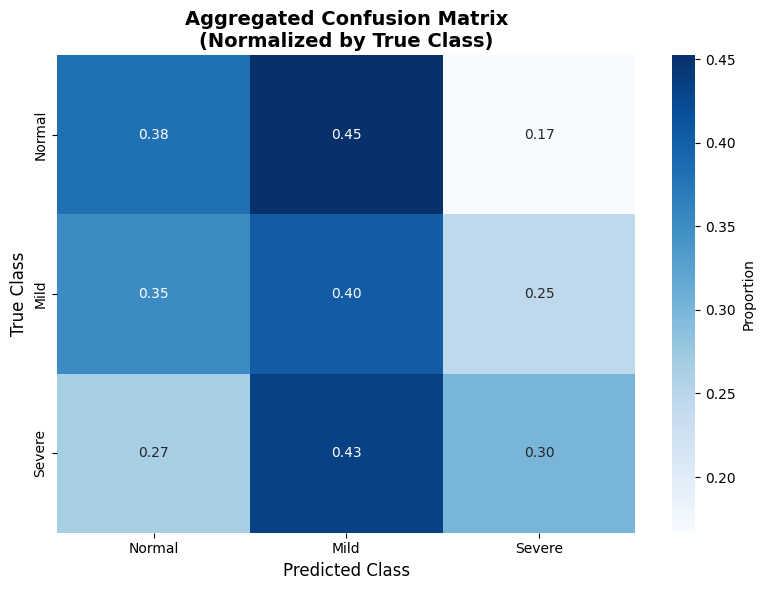


Aggregated Confusion Matrix (Counts):
[[16 19  7]
 [20 23 14]
 [ 8 13  9]]

Normalized Confusion Matrix (Row-wise):
[[0.38095238 0.45238095 0.16666667]
 [0.35087719 0.40350877 0.24561404]
 [0.26666667 0.43333333 0.3       ]]


In [22]:
# Plot aggregated confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))

cm = results['total_confusion_matrix']
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Proportion'}, ax=ax)

ax.set_xlabel('Predicted Class', fontsize=12)
ax.set_ylabel('True Class', fontsize=12)
ax.set_title('Aggregated Confusion Matrix\n(Normalized by True Class)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nAggregated Confusion Matrix (Counts):")
print(cm)
print("\nNormalized Confusion Matrix (Row-wise):")
print(cm_normalized)

In [23]:
# Classification report
from sklearn.metrics import classification_report

print("\n"+"="*80)
print("CLASSIFICATION REPORT (All Folds Combined)")
print("="*80)

y_true_all = np.array(results['all_y_true'])
y_pred_all = np.array(results['all_y_pred'])

report = classification_report(
    y_true_all, y_pred_all,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(report)

print("="*80)

# Save results to JSON
from datetime import datetime
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
results_file = output_dir / f"windowed_cv_results_{timestamp}.json"

# Prepare results for JSON serialization
json_results = {
    'timestamp': timestamp,
    'config': {k: (str(v) if isinstance(v, Path) else v) for k, v in config.items()},
    'mean_accuracy': float(results['mean_accuracy']),
    'std_accuracy': float(results['std_accuracy']),
    'mean_balanced_accuracy': float(results['mean_balanced_accuracy']),
    'std_balanced_accuracy': float(results['std_balanced_accuracy']),
    'mean_macro_f1': float(results['mean_macro_f1']),
    'std_macro_f1': float(results['std_macro_f1']),
    'confusion_matrix': results['total_confusion_matrix'].tolist(),
    'per_fold_metrics': [
        {
            'fold': r['fold'],
            'accuracy': float(r['metrics']['accuracy']),
            'balanced_accuracy': float(r['metrics']['balanced_accuracy']),
            'macro_f1': float(r['metrics']['macro_f1']),
            'per_class_recall': r['metrics']['per_class_recall'].tolist()
        }
        for r in results['fold_results']
    ]
}

with open(results_file, 'w') as f:
    json.dump(json_results, f, indent=2)

print(f"\nResults saved to: {results_file}")
print("\n"+"="*80)
print("EXPERIMENT COMPLETE!")
print("="*80)


CLASSIFICATION REPORT (All Folds Combined)
              precision    recall  f1-score   support

      Normal     0.3636    0.3810    0.3721        42
        Mild     0.4182    0.4035    0.4107        57
      Severe     0.3000    0.3000    0.3000        30

    accuracy                         0.3721       129
   macro avg     0.3606    0.3615    0.3609       129
weighted avg     0.3729    0.3721    0.3724       129


Results saved to: outputs\windowed_cv_results_20260302_170551.json

EXPERIMENT COMPLETE!
